# Model A — A7 à A10 : récence, assemblage P1, tournoi et incertitude

## Problème et leaders A3–A6

L'indice reste P1 = 100 × médiane(p_hat × g_hat) sur la cohorte connue à la coupure. historical_global est leader occurrence ; moyenne/médiane historiques sont les références growth. CORE seul, fondation immuable. Aucun forecast, entraînement final ou label 2026.

Les trois années 2023/2024/2025 servent à une comparaison empirique limitée et à une sélection rétrospective **non imbriquée**. Les scores après sélection peuvent être optimistes ; aucune significativité forte ni validation indépendante du champion n'est revendiquée.

In [1]:
from pathlib import Path
import sys,hashlib,subprocess,json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
ROOT=Path.cwd().resolve()
if ROOT.name=='notebooks':ROOT=ROOT.parent
sys.path.insert(0,str(ROOT))
from src.evaluation.model_a_tournament import run_tournament
from src.models.model_a import predict_from_fold, HALF_LIVES
from src.evaluation.model_a_uncertainty import historical_error_envelope,bootstrap_p1
frozen=['docs/modeling_contract.md','src/features/model_dataset.py','src/evaluation/backtest.py','src/same_unit.py','src/rent_economics.py','src/external_data.py']
protected=[ROOT/p for p in frozen]
protected+=list((ROOT/'data/raw').glob('*.csv'))+list((ROOT/'data/external').glob('*.csv'))
protected+=list((ROOT/'notebooks').glob('0[1-7]_*.ipynb'))+[ROOT/'notebooks/starter.ipynb']
protected+=[ROOT/p for p in ['docs/model_a_features.md','docs/model_a_modeling.md','src/features/model_a_features.py','src/models/model_a_occurrence.py','src/models/model_a_growth.py','src/evaluation/model_a_evaluation.py']]
hashes={p:hashlib.sha256(p.read_bytes()).hexdigest() for p in protected}
for p in frozen:
    original=subprocess.run(['git','show','foundation-v1:'+p],cwd=ROOT,capture_output=True,check=True).stdout
    assert original==(ROOT/p).read_bytes()
leases=pd.read_csv(ROOT/'data/raw/equinoxe_lease_history.csv',dtype={'sPropCode':'string','sUnitCode':'string'})
results=run_tournament(leases)
display(results['reference'])
assert results['reference'].candidates.tolist()==[405,645,856,931]
assert results['reference'].observed_units.iloc[:3].tolist()==[401,634,773]
assert set(results['_folds'])=={2023,2024,2025}
assert results['annual'].groupby('year').realized_P1_pct.nunique().eq(1).all()
print('Cohortes et références identiques ; garde 2026 de compatibilité uniquement, aucune prédiction 2026.')


/Users/massi.sadek/Desktop/POLYAIHACK_OCT2026/jadco-participants/jadco-rent-growth-forecast/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/massi.sadek/Desktop/POLYAIHACK_OCT2026/jadco-participants/jadco-rent-growth-forecast/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/massi.sadek/Desktop/POLYAIHACK_OCT2026/jadco-participants/jadco-rent-growth-forecast/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/massi.sadek/Desktop/POLYAIHACK_OCT2026/jadco-participants/jadco-rent-growth-forecast/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in m

/Users/massi.sadek/Desktop/POLYAIHACK_OCT2026/jadco-participants/jadco-rent-growth-forecast/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/massi.sadek/Desktop/POLYAIHACK_OCT2026/jadco-participants/jadco-rent-growth-forecast/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/massi.sadek/Desktop/POLYAIHACK_OCT2026/jadco-participants/jadco-rent-growth-forecast/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/massi.sadek/Desktop/POLYAIHACK_OCT2026/jadco-participants/jadco-rent-growth-forecast/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in m

/Users/massi.sadek/Desktop/POLYAIHACK_OCT2026/jadco-participants/jadco-rent-growth-forecast/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/massi.sadek/Desktop/POLYAIHACK_OCT2026/jadco-participants/jadco-rent-growth-forecast/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/massi.sadek/Desktop/POLYAIHACK_OCT2026/jadco-participants/jadco-rent-growth-forecast/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/massi.sadek/Desktop/POLYAIHACK_OCT2026/jadco-participants/jadco-rent-growth-forecast/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in m

,year,candidates,observed_units,prediction_origin
0,2023,405,401.0,2022-12-31
1,2024,645,634.0,2023-12-31
2,2025,856,773.0,2024-12-31
3,2026,931,NaN,2025-12-31


Cohortes et références identiques ; garde 2026 de compatibilité uniquement, aucune prédiction 2026.


## Expérience de récence

Âge = (prediction_origin − 31 décembre de l'année de l'observation).jours / 365,25. C'est un proxy annuel transparent, pas la date de signature ou de maturité du label. L'année doit être terminée à la coupure ; le stock de labels est **déjà qualifié par temporal_training**.

Trois variantes fixées : equal (lambda=0), mild (demi-vie 3 ans), moderate (demi-vie 1,5 an). w=exp(−ln(2)×âge/demi-vie). Taux occurrence et moyenne growth pondérés séparément. Médiane et modèles ML restent non pondérés ; aucun weighted median approximatif, ensemble ou sample_weight ajouté.

Le tournoi inclut une seule combinaison récente : meilleure variante **pondérée** d'occurrence au Brier moyen et meilleure variante **pondérée** de growth au MAE moyen. Ce choix réutilise les trois backtests ; son optimisme est explicite. Il n'implique pas que ces variantes battent equal.

In [2]:
display(pd.DataFrame([{'variante':k,'demi_vie_années':v,'lambda_par_an':0 if v is None else np.log(2)/v} for k,v in HALF_LIVES.items()]))
display(results['recency'].round(5))
display(results['recency'].groupby('variant',sort=False).agg(
    Brier_moyen=('occurrence_brier','mean'),Brier_pire=('occurrence_brier','max'),
    erreur_taux_absolue_moyenne=('rate_error_pp',lambda x:x.abs().mean()),
    MAE_growth_moyen=('mae_pp','mean'),RMSE_growth_moyen=('rmse_pp','mean')).round(5))


,variante,demi_vie_années,lambda_par_an
0,equal,NaN,0.000000
1,mild,3.0,0.231049
2,moderate,1.5,0.462098


,year,variant,occurrence_brier,predicted_transition_rate_pct,rate_error_pp,mae_pp,rmse_pp,bias_pp,median_absolute_error_pp,median_prediction,median_realized
0,2023,equal,0.00983,98.32776,-0.68459,3.83885,4.92681,0.66914,3.05446,2.89172,2.08537
1,2023,mild,0.00990,97.92701,-1.08534,3.87353,4.94913,0.81745,3.04002,3.04002,2.08537
2,2023,moderate,0.01002,97.44619,-1.56616,3.90679,4.97143,0.94309,3.11387,3.16566,2.08537
3,2024,equal,0.01677,98.47512,0.18055,4.72631,5.91327,1.50155,3.87371,3.42278,1.69962
4,2024,mild,0.01677,98.16142,-0.13316,4.82208,5.98454,1.76145,3.93151,3.68268,1.69962
5,2024,moderate,0.01679,97.79040,-0.50418,4.90731,6.05139,1.97667,4.06994,3.89791,1.69962
6,2025,equal,0.09378,98.18950,7.88576,4.25766,6.08104,-0.74715,2.62390,3.17583,3.71698
7,2025,mild,0.09291,97.61710,7.31336,4.25103,6.07511,-0.69719,2.60664,3.22580,3.71698
8,2025,moderate,0.09185,96.85418,6.55044,4.25573,6.07931,-0.73293,2.61411,3.19006,3.71698


,Brier_moyen,Brier_pire,erreur_taux_absolue_moyenne,MAE_growth_moyen,RMSE_growth_moyen
variant,,,,,
equal,0.04012,0.09378,2.91696,4.27427,5.64037
mild,0.03986,0.09291,2.84395,4.31555,5.66959
moderate,0.03955,0.09185,2.87359,4.35661,5.70071


## Assemblage P1 et tournoi

L'interface `predict_model_a` accepte occurrence_method, growth_method, recency_variant (chaîne commune ou dictionnaire occurrence/growth) et feature_set="core". Elle refuse 2026 à cette phase. Les contributions individuelles restent uniquement en mémoire ; elles ne sont jamais affichées ni exportées.

Sept candidats, aucun tuning ML supplémentaire. Réglages A3–A6 conservés. Ridge représente ici le challenger linéaire ; ElasticNet avait un comportement très voisin. Références réalisées exactes inchangées : environ 2,03610 / 1,60785 / 3,30088 %.

In [3]:
display(results['annual'].round(5))
display(results['ranking'].round(5))
print('Configurations exactes :')
print(json.dumps(results['configs'],ensure_ascii=False,indent=2))


,year,candidate,predicted_P1_pct,realized_P1_pct,error_pp,absolute_error_pp
0,2023,global_mean,2.84336,2.03610,0.80726,0.80726
1,2024,global_mean,3.37059,1.60785,1.76274,1.76274
2,2025,global_mean,3.11833,3.30088,-0.18255,0.18255
3,2023,recency_best,2.96239,2.03610,0.92628,0.92628
4,2024,recency_best,3.60131,1.60785,1.99345,1.99345
5,2025,recency_best,3.12432,3.30088,-0.17656,0.17656
6,2023,global_median,2.87006,2.03610,0.83396,0.83396
7,2024,global_median,3.26918,1.60785,1.66133,1.66133
8,2025,global_median,2.96933,3.30088,-0.33155,0.33155
9,2023,logistic_mean,2.84478,2.03610,0.80867,0.80867


,candidate,MAE_P1,RMSE_P1,bias_P1,worst_year_absolute_error,max_to_min_error_spread,occurrence_brier,growth_mae_pp,complexity_level,interpretability_level,max_degradation_vs_baseline_pp,eligible_for_promotion,rank
0,global_median,0.94228,1.09017,0.72124,1.66133,1.99288,0.04012,4.27180,0,0,0.14901,True,1
1,global_mean,0.91751,1.12431,0.79582,1.76274,1.94528,0.04012,4.27427,0,0,0.00000,True,2
2,logistic_mean,0.92103,1.14621,0.82284,1.80714,1.95443,0.07421,4.27427,2,2,0.04440,True,3
3,recency_best,1.03210,1.27319,0.91439,1.99345,2.17001,0.03955,4.31555,1,1,0.23072,True,4
4,logistic_hgb,1.65831,1.85835,0.93041,2.84408,3.93593,0.07421,4.61281,4,4,1.08134,False,5
5,global_hgb,1.77844,1.97925,1.15972,2.97146,3.89954,0.04012,4.61281,3,3,1.20873,False,6
6,global_ridge,2.80902,3.30385,2.80902,4.83348,4.24641,0.04012,5.09055,2,2,3.07074,False,7


Configurations exactes :
{
  "global_mean": {
    "occurrence_method": "historical_global",
    "growth_method": "historical_mean",
    "recency_variant": {
      "occurrence": "equal",
      "growth": "equal"
    },
    "feature_set": "core"
  },
  "recency_best": {
    "occurrence_method": "historical_global",
    "growth_method": "historical_mean",
    "recency_variant": {
      "occurrence": "moderate",
      "growth": "mild"
    },
    "feature_set": "core"
  },
  "global_median": {
    "occurrence_method": "historical_global",
    "growth_method": "historical_median",
    "recency_variant": {
      "occurrence": "equal",
      "growth": "equal"
    },
    "feature_set": "core"
  },
  "logistic_mean": {
    "occurrence_method": "Logistic",
    "growth_method": "historical_mean",
    "recency_variant": {
      "occurrence": "equal",
      "growth": "equal"
    },
    "feature_set": "core"
  },
  "global_ridge": {
    "occurrence_method": "historical_global",
    "growth_method": "R

## Stabilité par année et règle de sélection

Critère principal : MAE P1, années équipondérées. Équivalence pratique fixée à **0,05 pp** ; dans ce groupe, privilégier la simplicité, puis interprétabilité, pire erreur annuelle, RMSE, biais absolu, Brier occurrence et MAE growth. Ce seuil opérationnel n'est pas une preuve de significativité.

Garde de promotion fixé : refuser un candidat dont une erreur annuelle absolue dépasse celle du baseline global_mean de plus de **0,5 pp**. Tous ses résultats restent affichés. Aucun seuil n'est choisi d'après 2026. Le classement n'est donc pas un simple tri numérique du MAE.

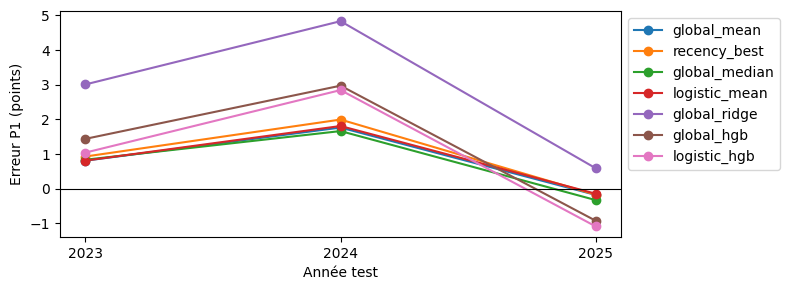

In [4]:
annual=results['annual']
fig,ax=plt.subplots(figsize=(8,3))
for name,g in annual.groupby('candidate',sort=False):
    ax.plot(g.year,g.error_pp,marker='o',label=name)
ax.axhline(0,color='black',linewidth=.8)
ax.set_xticks([2023,2024,2025]);ax.set_xlabel('Année test');ax.set_ylabel('Erreur P1 (points)')
ax.legend(bbox_to_anchor=(1,1));plt.tight_layout();plt.show()


## Champion et runner-up

Le plus faible MAE brut appartient à global_mean (0,91751 pp). global_median a un MAE de 0,94228 pp, soit **0,02476 pp** de plus : les deux sont pratiquement équivalents selon la règle fixée. Leur simplicité est identique ; global_median réduit la pire erreur (1,66133 contre 1,76274 pp), le RMSE (1,09017 contre 1,12431 pp) et le biais moyen (0,72124 contre 0,79582 pp).

**MODEL_A_CHAMPION = historical_global + historical_median, equal, CORE.**
**MODEL_A_RUNNER_UP = historical_global + historical_mean, equal, CORE.**

La médiane est un estimateur robuste de croissance conditionnelle, **pas une estimation littérale de E[G|transition]**. Elle est sélectionnée comme baseline autorisée pour prédire l'indice P1 inchangé ; ne pas présenter sa contribution comme une espérance exacte. La moyenne reste le challenger cohérent avec cette interprétation.

La récence améliore légèrement le Brier, mais détériore growth et P1 en moyenne. Logistic et les modèles complexes ne gagnent pas leur place.

In [5]:
print('Champion :',json.dumps(results['MODEL_A_CHAMPION'],ensure_ascii=False))
print('Runner-up :',json.dumps(results['MODEL_A_RUNNER_UP'],ensure_ascii=False))
report=results['explainability']
print(json.dumps(report,ensure_ascii=False,indent=2,allow_nan=False))


Champion : {"occurrence_method": "historical_global", "growth_method": "historical_median", "recency_variant": {"occurrence": "equal", "growth": "equal"}, "feature_set": "core"}
Runner-up : {"occurrence_method": "historical_global", "growth_method": "historical_mean", "recency_variant": {"occurrence": "equal", "growth": "equal"}, "feature_set": "core"}
{
  "model_name": "MODEL_A_CHAMPION",
  "candidate": "global_median",
  "occurrence_method": "historical_global",
  "growth_method": "historical_median",
  "recency_variant": {
    "occurrence": "equal",
    "growth": "equal"
  },
  "feature_set": "core",
  "backtest": [
    {
      "year": 2023,
      "candidate": "global_median",
      "predicted_P1_pct": 2.8700597508977657,
      "realized_P1_pct": 2.0361023490776855,
      "error_pp": 0.8339574018200802,
      "absolute_error_pp": 0.8339574018200802
    },
    {
      "year": 2024,
      "candidate": "global_median",
      "predicted_P1_pct": 3.2691787873371383,
      "realized_P1_pc

## Incertitude proposée

Méthode future, sans calcul des valeurs 2026 : 1 000 bootstraps des unités avec remplacement, seed=42 ; recalcul de 100×médiane des contributions fixes. Quantiles q10 et q90. Rayon d'erreur modèle **E=max(|e2023|,|e2024|,|e2025|)**, erreurs signées prédit−réalisé du champion conservées.

Formule fixée : **LOW=q10−E ; BASE=P1 ; HIGH=q90+E**. Ni correction de biais ni quantification arbitraire du drift. Ce sont des **scénarios**, pas un intervalle de confiance à 95 % ni une garantie de couverture.

Le bootstrap mesure seulement la sensibilité de la médiane au rééchantillonnage de contributions déjà prédites : pas de réentraînement, occurrence aléatoire ou résidus simulés. Pour ce champion global constant, toutes les contributions sont identiques : **largeur bootstrap nulle**. L'enveloppe historique fournit donc toute l'amplitude des scénarios ; elle reste fragile avec trois années sélectionnées rétrospectivement.

L'analyse ci-dessous décrit les contributions historiques et calibre la méthode après sélection sur les trois années ; elle n'est pas un backtest hors échantillon de couverture. Aucune valeur LOW/BASE/HIGH 2026 n'est calculée.

In [6]:
champion_name=report['candidate']
errors=annual.loc[annual.candidate.eq(champion_name)].sort_values('year')
display(pd.DataFrame([historical_error_envelope(errors)]))
bootstrap_checks=[]
for year in [2023,2024,2025]:
    assembled=predict_from_fold(results['_folds'][year],results['MODEL_A_CHAMPION'])
    boot=bootstrap_p1(assembled['contributions'],n_bootstrap=1000,random_state=42)
    q10,q90=np.quantile(boot,[.1,.9])
    bootstrap_checks.append({'année_historique':year,'q10_pct':q10,'q90_pct':q90,'largeur_pp':q90-q10})
display(pd.DataFrame(bootstrap_checks).round(6))
print('Méthode prête ; aucune valeur de scénario 2026 produite.')


,signed_errors_pp,model_error_radius_pp
0,"[0.8339574018200802, 1.6613263810901402, -0.33...",1.661326


,année_historique,q10_pct,q90_pct,largeur_pp
0,2023,2.870060,2.870060,0.0
1,2024,3.269179,3.269179,0.0
2,2025,2.969328,2.969328,0.0


Méthode prête ; aucune valeur de scénario 2026 produite.


## Dérive 2025, limites et conclusion

Le taux réalisé 2025 est 90,304 %, contre environ 98 % historiquement. Même moderate prévoit 96,854 % : la récence ne résout pas le drift. Ce facteur de risque reste explicitement dans l'objet d'explicabilité, sans ±X % inventé.

Trois années seulement, censure/maturité, fidélité CRM non prouvée, unités dépendantes au sein des bâtiments et sélection non imbriquée limitent les conclusions. Le bootstrap naïf des unités ne couvre pas cette dépendance ; l'enveloppe n'assure aucune protection contre événement exceptionnel, changement réglementaire ou erreur structurelle nouvelle. P1 reste un indice événementiel, pas une croissance du rent roll.

**GO pour A11–A13, CORE et configuration figée avant inspection 2026.** Scénarios honnêtement nommés, réserves explicites, aucun forecast dans A7–A10. Aucun CRM ou modèle individuel publié.

In [7]:
assert all(hashlib.sha256(p.read_bytes()).hexdigest()==v for p,v in hashes.items())
assert not subprocess.run(['git','diff','--cached','--name-only'],cwd=ROOT,capture_output=True,check=True).stdout
print('Validation finale : fondation, données et travaux A0–A6 inchangés ; aucun CRM staged, aucun forecast 2026.')


Validation finale : fondation, données et travaux A0–A6 inchangés ; aucun CRM staged, aucun forecast 2026.
